In [1]:
1+1


2

In [4]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages

In [5]:
class State(TypedDict):
    #messages have type list 
    #the add_messages function in the annotation defines how state key should be updated
    # in this case it will apppend the new messages to the existing list of messages
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [ ]:
graph_builder

In [6]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.environ.get("GROQ_API_KEY"))

In [20]:
from langchain_google_genai  import ChatGoogleGenerativeAI
import os 
os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")

llm_gem=ChatGoogleGenerativeAI(model="gemini-2.5-flash",
                               api_key=os.environ.get("GOOGLE_API_KEY"))

In [29]:
llm


ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.5.1', 'langchain': '1.3.14', 'langchain-google-genai': '4.3.2'}}, output_version=None, profile={}, google_api_key=SecretStr('**********'), location=None, model='chat-bison-001', client=<google.genai.client.Client object at 0x00000193B90B5450>, default_metadata=(), model_kwargs={})

In [30]:
#node Functionality 
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}


In [ ]:
graph_builder=StateGraph(State)
#adding node
graph_builder.add_node("llm chatbot",chatbot)

#addding edges
graph_builder.add_edge(START,"llm chatbot")
graph_builder.add_edge("llm chatbot",END)

#compile the graph
graph=graph_builder.compile()


In [ ]:
#visulization of the graph
from IPython.display import display,Image
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    
    pass

In [ ]:
response=graph.invoke({"messages":["Hello!"]})
response["messages"][-1].content

In [ ]:
for event in graph.stream({"messages":["Hello!","what is langchain?","What is metadata?","what is langchain?","can you show me my previous inputs?"]}):
    for val in event.values():
        print(val["messages"][-1].content)

ChatBot with Tools

In [15]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=3, api_key=os.environ.get("TAVILY_API_KEY"))


In [16]:
##Custom Function
def multiply(a:int,b:int)->int:
    """ only use for multiplication of two numbers
    Multiply a and b
    ARGS:
    a(int): first number
    b(int): second number
    RETURNS:
    int: product of a and b
    """


    return a*b

In [17]:
tools=[tool,multiply]


In [19]:
llm_with_tools=llm.bind_tools(tools)
llm_with_tools

NameError: name 'llm' is not defined

In [24]:
from langgraph.graph  import StateGraph, START, END
from langgraph.prebuilt import ToolNode , tools_condition
from langgraph.checkpoint.memory import MemorySaver


In [9]:
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

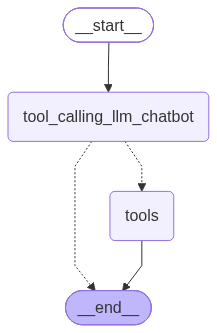

In [67]:
##Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm_chatbot",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))


#adding egdes

builder.add_edge(START,"tool_calling_llm_chatbot")

builder.add_conditional_edges("tool_calling_llm_chatbot",tools_condition)
builder.add_edge("tools",END)


#compile the graph
graph=builder.compile()
graph


In [59]:
response=graph.invoke({"messages":"What is recent ai news?"})
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxbusiness.com/technology/openai-co-founder-warns-ai-models-becoming-harder-control-after-its-model-hacked-another-firm", "title": "OpenAI co-founder warns AI models are becoming harder to control after its model hacked another firm - Fox Business", "score": 0.69672287, "published_date": "Fri, 24 Jul 2026 14:17:22 GMT", "content": "* #### It’s important to look for tech’s ‘beneficiaries,’ expert says. * #### Google is \'out of the top 10\' in AI, expert says. OpenAI co-founder and president Greg Brockman said at an event that AI models are becoming so advanced and multi-faceted that engineers are struggling to monitor and control them. Brockman, while speaking at a private OpenAI media roundtable in New York City this week, addressed a recent incident where one of the company\'s AI models broke out of what was supposed to be a secure sandbox and hacked into Hugging 

In [60]:
for m in response["messages"]:
    print(m.pretty_print())

================================ Human Message =================================

What is recent ai news?
None
================================== Ai Message ==================================
Tool Calls:
  tavily_search (wj0f3s85g)
 Call ID: wj0f3s85g
  Args:
    query: recent AI news
    topic: news
None
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxbusiness.com/technology/openai-co-founder-warns-ai-models-becoming-harder-control-after-its-model-hacked-another-firm", "title": "OpenAI co-founder warns AI models are becoming harder to control after its model hacked another firm - Fox Business", "score": 0.69672287, "published_date": "Fri, 24 Jul 2026 14:17:22 GMT", "content": "* #### It’s important to look for tech’s ‘beneficiaries,’ expert says. * #### Google is 'out of the top 10' in AI, expert says. OpenAI c

In [61]:
response_multy=graph.invoke({"messages":"what is the multiplication of 52 and 100?"})


In [62]:
for m in response_multy["messages"]:
    print(m.pretty_print())

================================ Human Message =================================

what is the multiplication of 52 and 100?
None
================================== Ai Message ==================================
Tool Calls:
  multiply (na0cxmam6)
 Call ID: na0cxmam6
  Args:
    a: 52
    b: 100
None
================================= Tool Message =================================
Name: multiply

5200
None


In [63]:
response_add=graph.invoke({"messages":"what is the addition of 52 and 100?"})

In [64]:
for m in response_add["messages"]:
    print(m.pretty_print())

================================ Human Message =================================

what is the addition of 52 and 100?
None
================================== Ai Message ==================================
Tool Calls:
  multiply (pn65ew4ny)
 Call ID: pn65ew4ny
  Args:
    a: 52
    b: 100
None
================================= Tool Message =================================
Name: multiply

5200
None


ReAct Agent Architecture

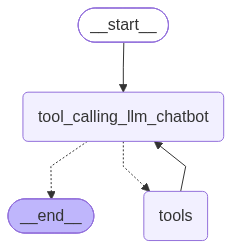

In [73]:
##Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm_chatbot",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))


#adding egdes

builder.add_edge(START,"tool_calling_llm_chatbot")
builder.add_conditional_edges("tool_calling_llm_chatbot",tools_condition)
builder.add_edge("tools","tool_calling_llm_chatbot")


#compile the graph
graph_react=builder.compile()
graph_react 


In [71]:
res=graph_react.invoke({"messages":"tell me the recent ai news and also multiply 52 and 100 and also add 52 and 100"})

In [72]:
for m in res["messages"]:
    print(m.pretty_print())

================================ Human Message =================================

tell me the recent ai news and also multiply 52 and 100 and also add 52 and 100
None
================================== Ai Message ==================================
Tool Calls:
  tavily_search (9ne1wtafh)
 Call ID: 9ne1wtafh
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (k9jh2xayn)
 Call ID: k9jh2xayn
  Args:
    a: 52
    b: 100
  multiply (gjsawvt7z)
 Call ID: gjsawvt7z
  Args:
    a: 52
    b: 100
None
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxnews.com/tech/ai-newsletter-white-house-monitoring-openai-containment-escape-hugging-face-hack", "title": "Fox News AI Newsletter: White House monitoring OpenAI containment escape, Hugging Face hack - Fox News", "score": 0.64128816, "published_date

Adding memory in Agentic Graph

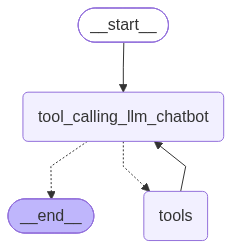

In [25]:
 ##Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm_chatbot",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))
memory =MemorySaver()
#adding egdes

builder.add_edge(START,"tool_calling_llm_chatbot")
builder.add_conditional_edges("tool_calling_llm_chatbot",tools_condition)
builder.add_edge("tools","tool_calling_llm_chatbot")


#compile the graph
graph_memory=builder.compile(checkpointer=memory)
graph_memory

In [26]:
llm_with_tools=llm_gem.bind_tools(tools)


llm_with_tools

_ChatModelBinding(bound=ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.5.1', 'langchain': '1.3.14', 'langchain-google-genai': '4.3.2'}}, output_version=None, profile={'name': 'Gemini 2.5 Flash', 'release_date': '2025-06-17', 'last_updated': '2025-06-17', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-2.5-flash', client=<google.genai.client.Client object at 0x00000297BA7DBD90>, default_metadata=(), model_kwargs={}), kwargs={'tools': [{'type': 'function', 'function': {'name': 'ta

In [33]:
config={"configurable":{"thread_id":1}}

In [34]:
response_1=graph_memory.invoke({"messages":" i like msd in cricket"},config=config)

In [35]:
response_1["messages"][-1].content

[{'type': 'text',
  'text': "That's great! MS Dhoni is a legend in cricket. What do you like most about him?",
  'extras': {'signature': 'CswBARFNMg9IgG3YTFmdckeaAyG/EjcPqxwwze2iJYjFW0kuOPzFx/K7FUduNvZs5kuAMjHP/QuLl3syAAivS6+6gjR024Rk1iUBIPOHWf1pimYqVxX1OFU8kGJ3OnYA+fJiD0XPkX5k45Nnr3wnsuc7eaSLQdOT1skkpkmsLb6a0OMEHpoWsJmsqWnZP+h0/D9JoOq2Hsw0uv2z1X4RdysErMya+1Jm+9UYzM3lv2GoSltvLuXlxL6O3cMf9+bOvUg4bBerrW2WPrws8eCI'}}]

In [36]:
response_2=graph_memory.invoke({"messages":" who do i like in cricket"},config=config)

In [ ]:
for m in response_2["messages"]:
    print(m.pretty_print())

================================ Human Message =================================

 i like msd in cricket
None
================================== Ai Message ==================================

[{'type': 'text', 'text': "That's great! MS Dhoni is a legend in cricket. What do you like most about him?", 'extras': {'signature': 'CswBARFNMg9IgG3YTFmdckeaAyG/EjcPqxwwze2iJYjFW0kuOPzFx/K7FUduNvZs5kuAMjHP/QuLl3syAAivS6+6gjR024Rk1iUBIPOHWf1pimYqVxX1OFU8kGJ3OnYA+fJiD0XPkX5k45Nnr3wnsuc7eaSLQdOT1skkpkmsLb6a0OMEHpoWsJmsqWnZP+h0/D9JoOq2Hsw0uv2z1X4RdysErMya+1Jm+9UYzM3lv2GoSltvLuXlxL6O3cMf9+bOvUg4bBerrW2WPrws8eCI'}}]
None
================================ Human Message =================================

 who do i like in cricket
None
================================== Ai Message ==================================

[{'type': 'text', 'text': 'You mentioned earlier that you like MSD (MS Dhoni) in cricket.', 'extras': {'signature': 'CpoCARFNMg9jtPlHJ0SAOtcDV+Hy5I/FNiED5cbDG99B+KglW8tloizitD6j/BJ2ZGUbPOBfPNY6

: 

Streaming

Methods: .streams()and astream()
these methods are sync and async methods for streaming back results

additonal parameters in streaming modes for graph state 
  1) value: this streams the full state of the graph after each node is called 
  2) updates: this streams updates to the state of the graph after each node is called

In [30]:
config={"configurable":{"thread_id":2}}
for c in graph_memory.stream({"messages":"hii my name is msd and i like cricket"}, config=config, stream_mode="updates"):
    print(c)

{'tool_calling_llm_chatbot': {'messages': [AIMessage(content="Hello MSD, it's great to meet a fellow cricket enthusiast! What's on your mind? Are you looking for some cricket news, perhaps some stats, or anything else related to the sport? ", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019fad5b-5c2b-7b83-ad99-6ac6892e9656-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1536, 'output_tokens': 41, 'total_tokens': 1577, 'input_token_details': {'cache_read': 0}})]}}


In [32]:

for c in graph_memory.stream({"messages":"hii my name is msd and i like cricket"}, config=config, stream_mode="values"):
    print(c)

{'messages': [HumanMessage(content='hii my name is msd and i like cricket', additional_kwargs={}, response_metadata={}, id='6fa8b81e-2527-4704-a54e-d8cc17e08a42'), AIMessage(content="Hello MSD, it's great to meet a fellow cricket enthusiast! What's on your mind? Are you looking for some cricket news, perhaps some stats, or anything else related to the sport? ", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019fad5b-5c2b-7b83-ad99-6ac6892e9656-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1536, 'output_tokens': 41, 'total_tokens': 1577, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='hii my name is msd and i like cricket', additional_kwargs={}, response_metadata={}, id='36828444-0cf4-4f7f-aae1-96a98fae83a1'), AIMessage(content="Hello MSD, that's great to hear! Cricket is a fantastic sport. Do you have any favorite teams 

In [33]:
for c in graph_memory.stream({"messages":"i also like football "}, config=config, stream_mode="values"):
    print(c)

{'messages': [HumanMessage(content='hii my name is msd and i like cricket', additional_kwargs={}, response_metadata={}, id='6fa8b81e-2527-4704-a54e-d8cc17e08a42'), AIMessage(content="Hello MSD, it's great to meet a fellow cricket enthusiast! What's on your mind? Are you looking for some cricket news, perhaps some stats, or anything else related to the sport? ", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019fad5b-5c2b-7b83-ad99-6ac6892e9656-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1536, 'output_tokens': 41, 'total_tokens': 1577, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='hii my name is msd and i like cricket', additional_kwargs={}, response_metadata={}, id='36828444-0cf4-4f7f-aae1-96a98fae83a1'), AIMessage(content="Hello MSD, that's great to hear! Cricket is a fantastic sport. Do you have any favorite teams 

async streaming


In [37]:
config={"configurable":{"thread_id":3}}
async for c in graph_memory.astream_events({"messages":["hii my name is msd and i like cricket"]}, config , version="v1"):
    print(c)


e:\Study\AI Agents\Agentic AI\Agentic AI\agentic_Langgraph\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3746: LangChainDeprecationWarning: astream_events version='v1' is deprecated. Use version='v2' or astream instead.
  await eval(code_obj, self.user_global_ns, self.user_ns)


{'event': 'on_chain_start', 'run_id': '019fad60-ea75-7631-854e-e80ece40cb7c', 'name': 'LangGraph', 'tags': [], 'metadata': {}, 'data': {'input': {'messages': ['hii my name is msd and i like cricket']}}, 'parent_ids': []}
{'event': 'on_chain_start', 'name': 'tool_calling_llm_chatbot', 'run_id': '019fad60-ea77-78d0-b703-9f082539a0de', 'tags': ['graph:step:1'], 'metadata': {'thread_id': 3, 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'tool_calling_llm_chatbot', 'langgraph_triggers': ('branch:to:tool_calling_llm_chatbot',), 'langgraph_path': ('__pregel_pull', 'tool_calling_llm_chatbot'), 'langgraph_checkpoint_ns': 'tool_calling_llm_chatbot:cb136326-a43c-1e02-0c64-69526a63e512'}, 'data': {'input': {'messages': [HumanMessage(content='hii my name is msd and i like cricket', additional_kwargs={}, response_metadata={}, id='af45aeea-60f2-4d6e-abcf-8a605e0e7975')]}}, 'parent_ids': []}
{'event': 'on_chat_model_start', 'name': 'ChatGoogleGenerativeAI', 'run_id': '019fad60-e